<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Semanal Nº5: Estimación espectral: Ancho de banda de señales reales
#### Ivana Rocio Miranda

## Introducción

El análisis espectral de señales permite caracterizar su contenido en frecuencia, es decir, determinar qué componentes frecuenciales están presentes y con qué potencia relativa. Este análisis es fundamental en el procesamiento de señales biomédicas y de audio, ya que cada tipo de señal ocupa una banda característica del espectro.

La **Densidad Espectral de Potencia (PSD)** describe cómo se distribuye la potencia de una señal en función de la frecuencia. Para señales reales de duración finita, no es posible calcular la PSD exacta; en su lugar se recurre a estimadores. En este trabajo se utiliza el **Periodograma**, que consiste en calcular el módulo al cuadrado de la Transformada de Fourier de la señal:

$$\hat{S}(f) = \frac{1}{N} \left| \sum_{n=0}^{N-1} x[n]\, e^{-j2\pi f n / f_s} \right|^2$$

El **ancho de banda** de una señal puede definirse de diversas maneras. En este trabajo se utiliza el criterio del **99% de la energía espectral**: se integra la PSD desde 0 Hz hasta encontrar la frecuencia $f_{BW}$ tal que el área acumulada represente el 99% de la potencia total. Este criterio es robusto y no depende de un umbral fijo en dB.

Se analizan tres tipos de señales:
- **ECG** (Electrocardiograma): señal biomédica que refleja la actividad eléctrica del corazón.
- **PPG** (Pletismografía): señal que mide variaciones de volumen sanguíneo en tejido periférico.
- **Audio**: señal de voz/melodía cuyo espectro se extiende hasta varios kilohertz.

## Importación de librerías

In [1]:
import numpy as np
from scipy import signal as sig

import matplotlib.pyplot as plt
   
import scipy.io as sio
from scipy.io.wavfile import write
import spectrum as sp

---

## 1. Lectura de señales

Se cargan las tres señales a analizar. Cada una fue adquirida con una frecuencia de muestreo distinta, acorde a su ancho de banda esperado:
- ECG a 1000 Hz
- PPG a 400 Hz
- Audio a la frecuencia nativa del archivo `.wav`

### 1.1 Lectura de ECG

In [2]:
fs_ecg = 1000 # Hz
ecg = np.load('/home/miranda/analisis_senales/TS5/ecg_sin_ruido.npy')

### 1.2 Lectura de pletismografía (PPG)

In [3]:
fs_ppg = 400 # Hz
ppg = np.load('/home/miranda/analisis_senales/TS5/ppg_sin_ruido.npy')

### 1.3 Lectura de audio
Entre los tres audios se eligió el audio "la cucaracha", en caso de querer estudiar alguno de los otros audios solo se descomenta el deseado y se comentan el resto.

In [4]:
fs_audio, wav_data = sio.wavfile.read('/home/miranda/analisis_senales/TS5/la cucaracha.wav')
# fs_audio, wav_data = sio.wavfile.read('/home/miranda/analisis_senales/TS5/prueba psd.wav')
# fs_audio, wav_data = sio.wavfile.read('/home/miranda/analisis_senales/TS5/silbido.wav')

---

## 2. Estimación del ancho de banda al 99% de energía

Se define una función que calcula la PSD mediante el método de Welch y determina el **ancho de banda al 99%** de la potencia total acumulada. 

El método de Welch promedia periodogramas sobre segmentos solapados de la señal, reduciendo la varianza del estimador a costa de cierta resolución frecuencial. Para el cálculo del ancho de banda, se acumula la potencia en la PSD resultante y se identifica la frecuencia donde se supera el 99% de la potencia total.

In [5]:
def ancho_banda_99(senal, fs, nperseg=1024):
    # PSD en escala lineal
    f, Pxx = sig.welch(senal, fs=fs, nperseg=nperseg)

    # Potencia acumulada
    potencia_total = np.sum(Pxx)
    potencia_acumulada = np.cumsum(Pxx)

    # Frecuencia donde se alcanza el 99% de la potencia
    indice = np.where(potencia_acumulada >= 0.99 * potencia_total)[0][0]
    bw = f[indice]

    return bw, f, Pxx

### 2.1 Ancho de banda — ECG

La señal de ECG concentra la mayor parte de su energía en frecuencias bajas. Las ondas características (P, QRS, T), que son las ondas que componen al latido cardíaco, tienen componentes predominantes por debajo de los 40–50 Hz, aunque el complejo QRS, por su alta pendiente, puede extenderse un poco más. Se espera un ancho de banda en el orden de los 40–100 Hz dependiendo del tipo de registro.

In [6]:
#%% ECG
bw_ecg, f_ecg, Pxx_ecg = ancho_banda_99(ecg, fs_ecg)

### 2.2 Ancho de banda — PPG

La señal de PPG está dominada por la frecuencia cardíaca fundamental y sus armónicos, todos ellos por debajo de unos pocos hertz. Se trata de una señal de muy bajo ancho de banda en comparación con el ECG o el audio, típicamente contenida por debajo de los 10–20 Hz.

In [7]:
#%% PPG
bw_ppg, f_ppg, Pxx_ppg = ancho_banda_99(ppg, fs_ppg)

### 2.3 Ancho de banda — Audio

Las señales de audio, particularmente de voz y melodías silbadas, poseen un espectro mucho más amplio. La voz humana típicamente ocupa entre 300 Hz y 3400 Hz (banda telefónica), aunque en grabaciones de alta calidad puede llegar a varios kilohertz. El ancho de banda al 99% reflejará la extensión real de la energía en el registro analizado.

In [8]:
#%% Audio

bw_audio, f_audio, Pxx_audio = ancho_banda_99(wav_data, fs_audio)

### 2.4 Resultados — Tabla de anchos de banda

Se presentan los anchos de banda estimados para las tres señales. La diferencia de órdenes de magnitud refleja la naturaleza de cada señal: las biomédicas (ECG, PPG) son de baja frecuencia, mientras que el audio ocupa una banda mucho más amplia.

In [9]:
#%% Resultados

print(f"Ancho de banda (99%) ECG   : {bw_ecg:.2f} Hz")
print(f"Ancho de banda (99%) PPG   : {bw_ppg:.2f} Hz")
print(f"Ancho de banda (99%) Audio : {bw_audio:.2f} Hz")

Ancho de banda (99%) ECG   : 31.25 Hz
Ancho de banda (99%) PPG   : 5.47 Hz
Ancho de banda (99%) Audio : 2015.62 Hz


---

## 3. Estimación Espectral mediante el Periodograma

A continuación se calcula y grafica la PSD de cada señal utilizando el **Periodograma** de la librería `spectrum`. Este estimador calcula directamente la DFT de toda la señal, por lo que tiene alta resolución frecuencial pero también alta varianza (el espectro puede verse "ruidoso"). La PSD se representa en escala logarítmica (dB) para facilitar la visualización de componentes de distinta amplitud.

### 3.1 PSD — ECG (Periodograma)

En el espectro del ECG se observa que la potencia se concentra en las frecuencias bajas. La región de alta frecuencia decae rápidamente, confirmando que la mayor parte de la energía está por debajo de los 100 Hz.

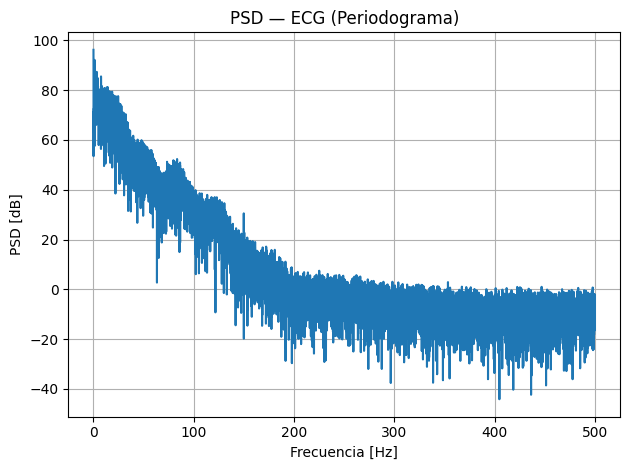

In [10]:
#%% ESTIMACIÓN ESPECTRAL 
 
# ══════════════════════════════════════════════════════════════
#  PSD — ECG
# ══════════════════════════════════════════════════════════════
 
N_ecg = len(ecg)
df_ecg = fs_ecg / N_ecg
ff_ecg = np.linspace(0, (N_ecg - 1) * df_ecg, N_ecg)
 
pP_ecg = sp.Periodogram(ecg, sampling=fs_ecg, NFFT=N_ecg)
 
plt.figure(1)
plt.plot(ff_ecg[:N_ecg//2 + 1], 10 * np.log10(pP_ecg.psd))
plt.title('PSD — ECG (Periodograma)')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB]')
plt.grid(which='both', axis='both')
plt.tight_layout()

### 3.2 PSD — PPG (Periodograma)

El espectro de la PPG muestra picos discretos bien definidos, correspondientes a la frecuencia cardíaca fundamental y sus armónicos. La señal es casi periódica (con pequeñas variaciones latido a latido), lo que genera un espectro con estructura armónica clara. La energía cae drásticamente a partir del segundo o tercer armónico, revelando el carácter de muy bajo ancho de banda de esta señal.

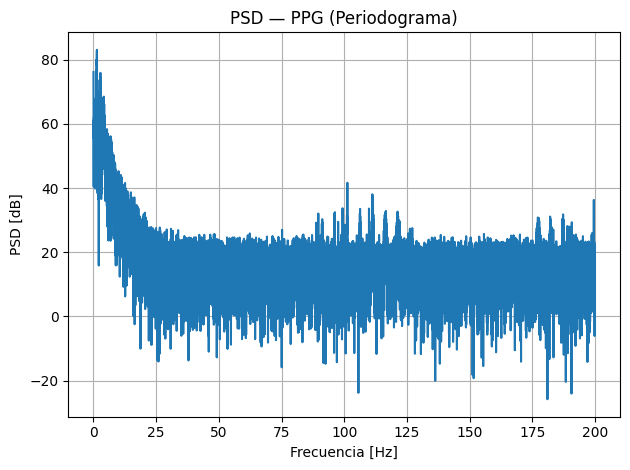

In [11]:
# ══════════════════════════════════════════════════════════════
#  PSD — PPG
# ══════════════════════════════════════════════════════════════
 
N_ppg = len(ppg)
df_ppg = fs_ppg / N_ppg
ff_ppg = np.linspace(0, (N_ppg - 1) * df_ppg, N_ppg)
 
pP_ppg = sp.Periodogram(ppg, sampling=fs_ppg, NFFT=N_ppg)
 
plt.figure(2)
plt.plot(ff_ppg[:N_ppg//2 + 1], 10 * np.log10(pP_ppg.psd))
plt.title('PSD — PPG (Periodograma)')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB]')
plt.grid(which='both', axis='both')
plt.tight_layout()

### 3.3 PSD — Audio (Periodograma)

El espectro del audio presenta una distribución mucho más ancha que las señales biomédicas. En una melodía silbada o en voz, se aprecian componentes en un rango amplio de frecuencias. La variabilidad del periodograma es notable en audio por la naturaleza no estacionaria de la señal; aun así, permite identificar las frecuencias predominantes de la melodía o los formantes de la voz.

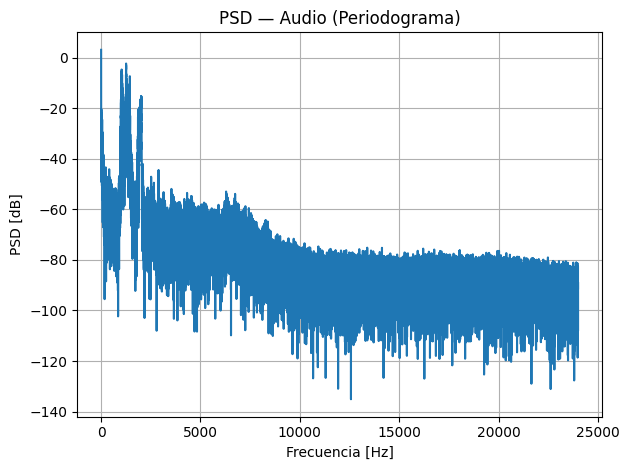

In [12]:
# ══════════════════════════════════════════════════════════════
#  PSD — AUDIO
# ══════════════════════════════════════════════════════════════
 
N_audio = len(wav_data)
df_audio = fs_audio / N_audio
ff_audio = np.linspace(0, (N_audio - 1) * df_audio, N_audio)
 
pP_audio = sp.Periodogram(wav_data, sampling=fs_audio, NFFT=N_audio)
 
plt.figure(3)
plt.plot(ff_audio[:N_audio//2 + 1], 10 * np.log10(pP_audio.psd))
plt.title('PSD — Audio (Periodograma)')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB]')
plt.grid(which='both', axis='both')
plt.tight_layout()
 
 
plt.show()

---

## 4. PSD en escala dB — Welch

A continuación se convierten las PSD obtenidas por Welch (usadas para el cálculo del ancho de banda) a escala logarítmica, para permitir una visualización complementaria.

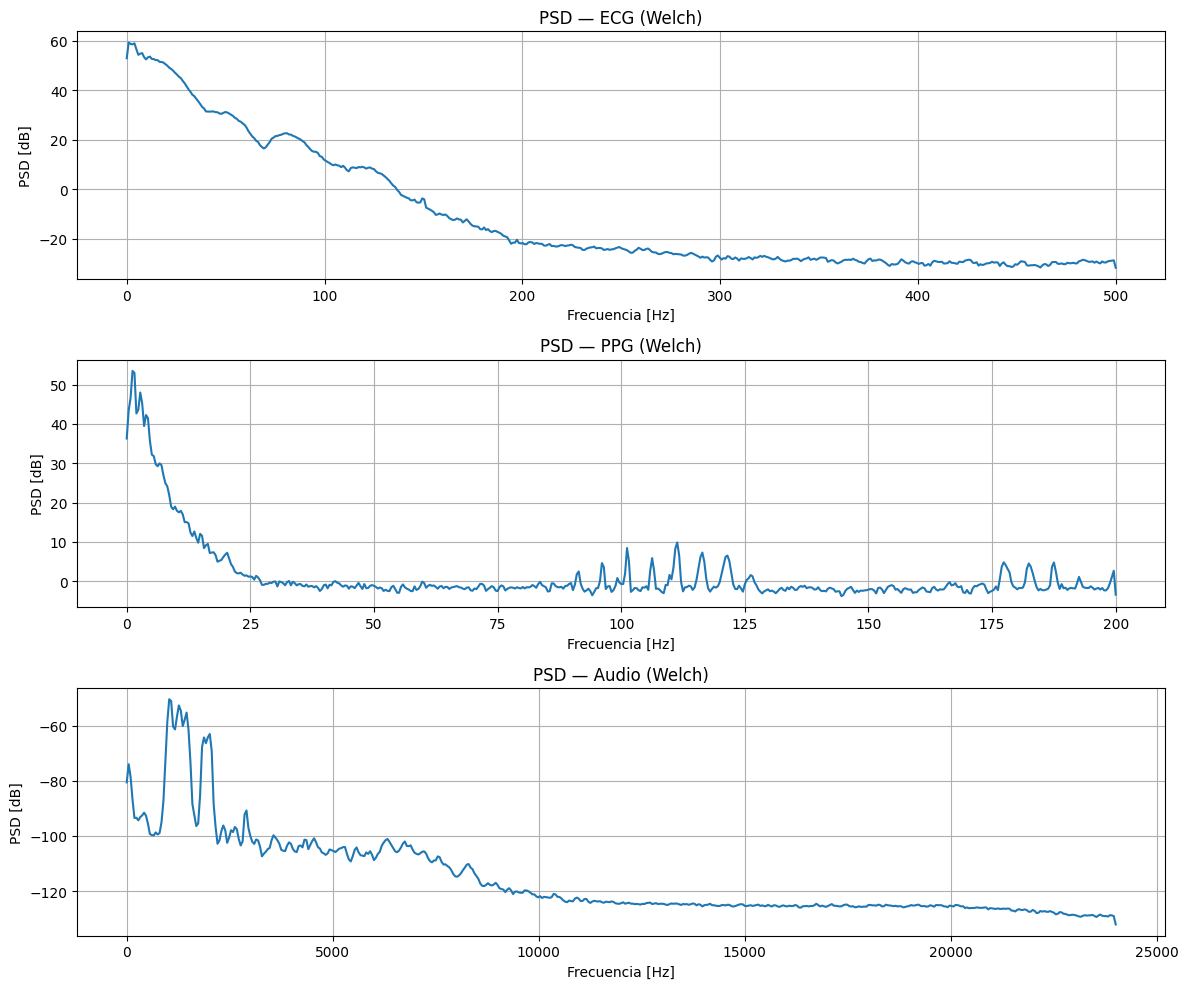

In [17]:
#%% AUDIO
Pxx_denaudiodb  = 10 * np.log10(Pxx_audio)

#%% PPG
Pxx_denppg = 10 * np.log10(Pxx_ppg)

#%% ECG
Pxx_denecg  = 10 * np.log10(Pxx_ecg)
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# ── ECG ──
axes[0].plot(f_ecg, Pxx_denecg)
axes[0].set_title('PSD — ECG (Welch)')
axes[0].set_xlabel('Frecuencia [Hz]')
axes[0].set_ylabel('PSD [dB]')
axes[0].grid(True)

# ── PPG ──
axes[1].plot(f_ppg, Pxx_denppg)
axes[1].set_title('PSD — PPG (Welch)')
axes[1].set_xlabel('Frecuencia [Hz]')
axes[1].set_ylabel('PSD [dB]')
axes[1].grid(True)

# ── AUDIO ──
axes[2].plot(f_audio, Pxx_denaudiodb)
axes[2].set_title('PSD — Audio (Welch)')
axes[2].set_xlabel('Frecuencia [Hz]')
axes[2].set_ylabel('PSD [dB]')
axes[2].grid(True)

plt.tight_layout()
plt.show()

---

## 5. Conclusiones

A partir del análisis espectral realizado, se puede llegar a las siguientes conclusiones:

- La **PPG** es la señal de menor ancho de banda entre las analizadas. Su contenido espectral se concentra en la frecuencia cardíaca y sus primeros armónicos, todos ellos por debajo de pocos hertz.

- El **ECG** presenta un ancho de banda considerablemente mayor que la PPG, debido principalmente al complejo QRS, que contiene componentes de alta frecuencia relativa dentro del rango biomédico.

- El **audio** tiene el mayor ancho de banda de los tres, con energía distribuida en un rango de varios kilohertz, coherente con las características perceptuales del oído humano y de las fuentes sonoras analizadas.

- El criterio del **99% de energía** resulta útil para definir objetivamente el ancho de banda sin necesidad de fijar un umbral arbitrario en dB.

- El **Periodograma** permite una visualización detallada del espectro, aunque con alta varianza. Para la estimación del ancho de banda se prefirió el método de **Welch** por su menor varianza y mayor robustez estadística.